Dataset Loaded Successfully!

   age  age group eligible           job  salary  marital  education  \
0   58          5        Y    management  100000  married   tertiary   
1   44          4        Y    technician   60000   single  secondary   
2   33          3        Y  entrepreneur  120000  married  secondary   
3   47          4        Y   blue-collar   20000  married    unknown   
4   33          3        Y       unknown       0   single    unknown   

   marital-education targeted default  ...  contact day month duration  \
0   married-tertiary      yes      no  ...  unknown   5   may      261   
1   single-secondary      yes      no  ...  unknown   5   may      151   
2  married-secondary      yes      no  ...  unknown   5   may       76   
3    married-unknown       no      no  ...  unknown   5   may       92   
4     single-unknown       no      no  ...  unknown   5   may      198   

   campaign pdays  previous  poutcome   y  response  
0         1    -1         0   unknown 

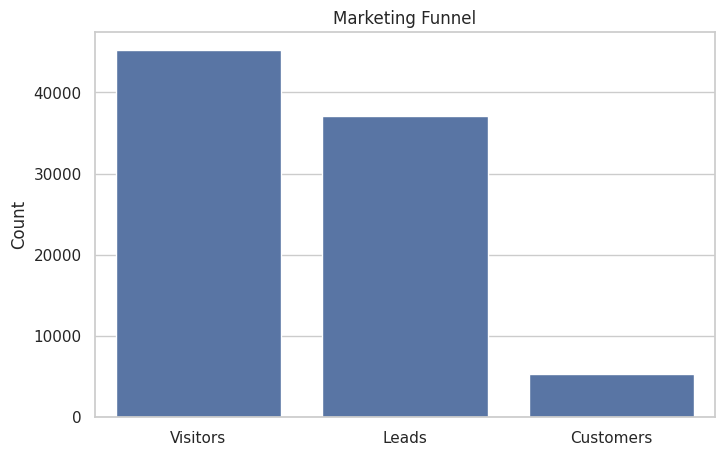


========== CHANNEL PERFORMANCE ==========
           Visitors  Leads  Customers  Visitor_to_Lead_%  Lead_to_Customer_%
contact                                                                     
cellular      29285  23573       4369          80.495134           18.533916
telephone      2906   2459        390          84.618032           15.860106
unknown       13020  11059        530          84.938556            4.792477


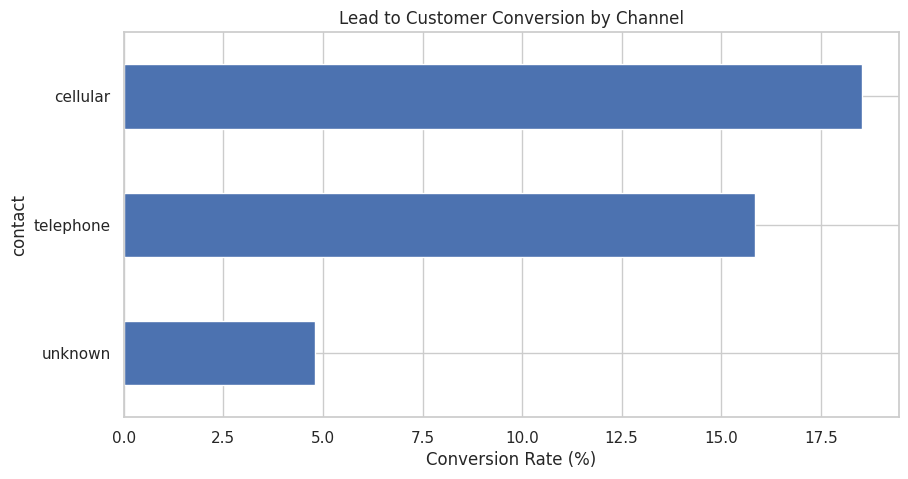


========== CAMPAIGN PERFORMANCE ==========
          Visitors  Leads  Customers  Overall_Conversion_%
campaign                                                  
1            17544  14290       2561             14.597583
2            12505  10276       1401             11.203519
3             5521   4586        618             11.193624
4             3522   2907        317              9.000568
5             1764   1471        139              7.879819
6             1291   1062         92              7.126259
7              735    605         47              6.394558
8              540    448         32              5.925926
9              327    260         21              6.422018
10             266    226         14              5.263158
11             201    164         16              7.960199
12             155    127          4              2.580645
13             133    108          6              4.511278
14              93     77          4              4.301075
15          

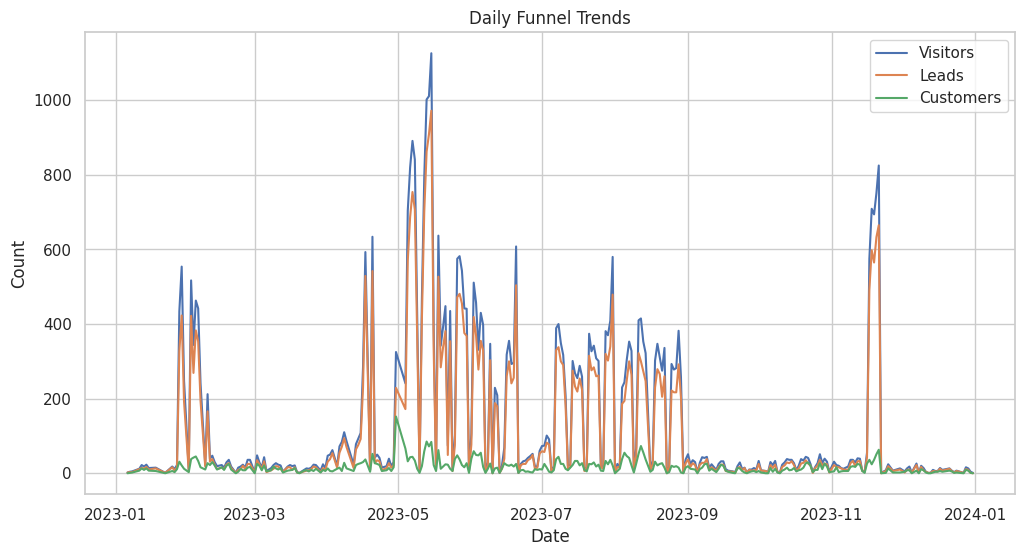


Best Performing Channel:
cellular

========== KEY INSIGHTS ==========
- Some channels generate high traffic but low conversions.
- Certain campaigns perform better in customer acquisition.
- Major drop-off occurs between visitor and lead stage.
- High-converting channels should receive more budget.

========== RECOMMENDATIONS ==========
1. Optimize landing pages to improve lead conversion.
2. Invest more in high-performing channels.
3. Improve lead nurturing process.
4. Reduce funnel drop-offs using targeted campaigns.
5. Monitor campaign performance weekly.

Analysis Completed Successfully!


In [10]:
# ==========================================
# MARKETING FUNNEL & CONVERSION ANALYSIS
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style
sns.set(style="whitegrid")

# ==========================================
# STEP 1: LOAD DATA
# ==========================================

# Load dataset
df = pd.read_csv("bank-marketing.csv")

print("Dataset Loaded Successfully!\n")

# Display first rows
print(df.head())

# ==========================================
# STEP 2: DATA CLEANING
# ==========================================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing rows
df.dropna(inplace=True)

# Convert Date column
df['Date'] = df['day'].astype(str) + '-' + df['month'].astype(str) + '-2023'
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%Y')

# Create new columns for funnel stages
df['is_visitor'] = 1
df['is_lead'] = df['targeted'].apply(lambda x: 1 if x == 'yes' else 0)
df['is_customer'] = df['response']

print("\nData Cleaning Completed!")

# ==========================================
# STEP 3: BASIC METRICS
# ==========================================

total_visitors = df['is_visitor'].sum()
total_leads = df['is_lead'].sum()
total_customers = df['is_customer'].sum()

print("\n========== OVERALL METRICS ==========")
print(f"Total Visitors: {total_visitors}")
print(f"Total Leads: {total_leads}")
print(f"Total Customers: {total_customers}")

# ==========================================
# STEP 4: CONVERSION RATES
# ==========================================

visitor_to_lead = (total_leads / total_visitors) * 100
lead_to_customer = (total_customers / total_leads) * 100
overall_conversion = (total_customers / total_visitors) * 100

print("\n========== CONVERSION RATES ==========")
print(f"Visitor to Lead Conversion: {visitor_to_lead:.2f}%")
print(f"Lead to Customer Conversion: {lead_to_customer:.2f}%")
print(f"Overall Funnel Conversion: {overall_conversion:.2f}%")

# ==========================================
# STEP 5: FUNNEL VISUALIZATION
# ==========================================

stages = ['Visitors', 'Leads', 'Customers']
values = [total_visitors, total_leads, total_customers]

plt.figure(figsize=(8,5))
sns.barplot(x=stages, y=values)

plt.title("Marketing Funnel")
plt.ylabel("Count")
plt.show()

# ==========================================
# STEP 6: CHANNEL PERFORMANCE
# ==========================================

channel_analysis = df.groupby('contact').agg({
    'is_visitor': 'sum',
    'is_lead': 'sum',
    'is_customer': 'sum'
})
channel_analysis.rename(columns={'is_visitor': 'Visitors', 'is_lead': 'Leads', 'is_customer': 'Customers'}, inplace=True)

# Calculate conversion rates
channel_analysis['Visitor_to_Lead_%'] = (
    channel_analysis['Leads'] /
    channel_analysis['Visitors']
) * 100

channel_analysis['Lead_to_Customer_%'] = (
    channel_analysis['Customers'] /
    channel_analysis['Leads']
) * 100

print("\n========== CHANNEL PERFORMANCE ==========")
print(channel_analysis)

# ==========================================
# STEP 7: VISUALIZE CHANNEL PERFORMANCE
# ==========================================

plt.figure(figsize=(10,5))

channel_analysis['Lead_to_Customer_%'].sort_values().plot(kind='barh')

plt.title("Lead to Customer Conversion by Channel")
plt.xlabel("Conversion Rate (%)")
plt.show()

# ==========================================
# STEP 8: CAMPAIGN PERFORMANCE
# ==========================================

campaign_analysis = df.groupby('campaign').agg({
    'is_visitor': 'sum',
    'is_lead': 'sum',
    'is_customer': 'sum'
})
campaign_analysis.rename(columns={'is_visitor': 'Visitors', 'is_lead': 'Leads', 'is_customer': 'Customers'}, inplace=True)

campaign_analysis['Overall_Conversion_%'] = (
    campaign_analysis['Customers'] /
    campaign_analysis['Visitors']
) * 100

print("\n========== CAMPAIGN PERFORMANCE ==========")
print(campaign_analysis)

# ==========================================
# STEP 9: DROP-OFF ANALYSIS
# ==========================================

visitor_drop = total_visitors - total_leads
lead_drop = total_leads - total_customers

print("\n========== DROP-OFF ANALYSIS ==========")
print(f"Visitors Lost Before Becoming Leads: {visitor_drop}")
print(f"Leads Lost Before Becoming Customers: {lead_drop}")

# ==========================================
# STEP 10: TIME-BASED TREND ANALYSIS
# ==========================================

daily_trend = df.groupby('Date').agg({
    'is_visitor': 'sum',
    'is_lead': 'sum',
    'is_customer': 'sum'
})
daily_trend.rename(columns={'is_visitor': 'Visitors', 'is_lead': 'Leads', 'is_customer': 'Customers'}, inplace=True)

plt.figure(figsize=(12,6))

plt.plot(daily_trend.index, daily_trend['Visitors'], label='Visitors')
plt.plot(daily_trend.index, daily_trend['Leads'], label='Leads')
plt.plot(daily_trend.index, daily_trend['Customers'], label='Customers')

plt.title("Daily Funnel Trends")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()

plt.show()

# ==========================================
# STEP 11: BEST PERFORMING CHANNEL
# ==========================================

best_channel = channel_analysis['Lead_to_Customer_%'].idxmax()

print("\nBest Performing Channel:")
print(best_channel)

# ==========================================
# STEP 12: KEY INSIGHTS
# ==========================================

print("\n========== KEY INSIGHTS ==========")

print("- Some channels generate high traffic but low conversions.")
print("- Certain campaigns perform better in customer acquisition.")
print("- Major drop-off occurs between visitor and lead stage.")
print("- High-converting channels should receive more budget.")

# ==========================================
# STEP 13: BUSINESS RECOMMENDATIONS
# ==========================================

print("\n========== RECOMMENDATIONS ==========")

print("1. Optimize landing pages to improve lead conversion.")
print("2. Invest more in high-performing channels.")
print("3. Improve lead nurturing process.")
print("4. Reduce funnel drop-offs using targeted campaigns.")
print("5. Monitor campaign performance weekly.")

# ==========================================
# STEP 14: SAVE ANALYSIS
# ==========================================

channel_analysis.to_csv("channel_performance.csv")

print("\nAnalysis Completed Successfully!")